# **Extracting Information from Legal Documents Using RAG**

## **Objective**

The main objective of this assignment is to process and analyse a collection text files containing legal agreements (e.g., NDAs) to prepare them for implementing a **Retrieval-Augmented Generation (RAG)** system. This involves:

* Understand the Cleaned Data : Gain a comprehensive understanding of the structure, content, and context of the cleaned dataset.
* Perform Exploratory Analysis : Conduct bivariate and multivariate analyses to uncover relationships and trends within the cleaned data.
* Create Visualisations : Develop meaningful visualisations to support the analysis and make findings interpretable.
* Derive Insights and Conclusions : Extract valuable insights from the cleaned data and provide clear, actionable conclusions.
* Document the Process : Provide a detailed description of the data, its attributes, and the steps taken during the analysis for reproducibility and clarity.

The ultimate goal is to transform the raw text data into a clean, structured, and analysable format that can be effectively used to build and train a RAG system for tasks like information retrieval, question-answering, and knowledge extraction related to legal agreements.

### **Business Value**  


The project aims to leverage RAG to enhance legal document processing for businesses, law firms, and regulatory bodies. The key business objectives include:

* Faster Legal Research: <br> Reduce the time lawyers and compliance officers spend searching for relevant case laws, precedents, statutes, or contract clauses.
* Improved Contract Analysis: <br> Automatically extract key terms, obligations, and risks from lengthy contracts.
* Regulatory Compliance Monitoring: <br> Help businesses stay updated with legal and regulatory changes by retrieving relevant legal updates.
* Enhanced Decision-Making: <br> Provide accurate and context-aware legal insights to assist in risk assessment and legal strategy.


**Use Cases**
* Legal Chatbots
* Contract Review Automation
* Tracking Regulatory Changes and Compliance Monitoring
* Case Law Analysis of past judgments
* Due Diligence & Risk Assessment

## **1. Data Loading, Preparation and Analysis** <font color=red> [20 marks] </font><br>

### **1.1 Data Understanding**

The dataset contains legal documents and contracts collected from various sources. The documents are present as text files (`.txt`) in the *corpus* folder.

There are four types of documents in the *courpus* folder, divided into four subfolders.
- `contractnli`: contains various non-disclosure and confidentiality agreements
- `cuad`: contains contracts with annotated legal clauses
- `maud`: contains various merger/acquisition contracts and agreements
- `privacy_qa`: a question-answering dataset containing privacy policies

The dataset also contains evaluation files in JSON format in the *benchmark* folder. The files contain the questions and their answers, along with sources. For the above folders, there is a `json` file: `contractnli.json`, `cuad.json`, `maud.json`. The file structure is as follows:

```
{
    "tests": [
        {
            "query": <question1>,
            "snippets": [{
                    "file_path": <source_file1>,
                    "span": [ begin_position, end_position ],
                    "answer": <relevant answer to the question 1>
                },
                {
                    "file_path": <source_file2>,
                    "span": [ begin_position, end_position ],
                    "answer": <relevant answer to the question 2>
                }, ....
            ]
        },
        {
            "query": <question2>,
            "snippets": [{<answer context for que 2>}]
        },
        ... <more queries>
    ]
}
```

### **1.2 Load and Preprocess the data** <font color=red> [5 marks] </font><br>

#### Loading libraries

In [3]:
## The following libraries might be useful
# !pip install -q langchain-openai
# !pip install -U -q langchain-community
# !pip install -U -q langchain-chroma
# !pip install -U -q datasets
# !pip install -U -q ragas
# !pip install -U -q rouge_score

In [3]:
# Import essential libraries

import os
import json
import re
from pathlib import Path
from collections import Counter

import nltk
from nltk.corpus import stopwords

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

from langchain.text_splitter import RecursiveCharacterTextSplitter
from langchain_community.vectorstores import Chroma
from langchain_huggingface import HuggingFaceEmbeddings

from rouge_score import rouge_scorer

# import sys
# print(sys.executable)

/Users/abinas/Documents/machine-learning/C8-designing-genai/RAG_assignment/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(
/Users/abinas/Documents/machine-learning/C8-designing-genai/RAG_assignment/.venv/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


#### **1.2.1** <font color=red> [3 marks] </font>
Load all `.txt` files from the folders.

You can utilise document loaders from the options provided by the LangChain community.

Optionally, you can also read the files manually, while ensuring proper handling of encoding issues (e.g., utf-8, latin1). In such case, also store the file content along with metadata (e.g., file name, directory path) for traceability.

In [6]:
# Load the files as documents
corpus_path = Path("rag_legal/corpus")
documents = []

for folder in corpus_path.iterdir():
    if folder.is_dir():
        for file in folder.glob("*.txt"):
            try:
                text = file.read_text(encoding="utf-8")
            except UnicodeDecodeError:
                text = file.read_text(encoding="latin-1")
            
            documents.append({
                "text": text,
                "metadata": {
                    "source": folder.name,
                    "file_name": file.name,
                    "file_path": str(file)
                }
            })

print(f"Total documents loaded: {len(documents)}")


Total documents loaded: 644


#### **1.2.2** <font color=red> [2 marks] </font>
Preprocess the text data to remove noise and prepare it for analysis.

Remove special characters, extra whitespace, and irrelevant content such as email and telephone contact info.
Normalise text (e.g., convert to lowercase, remove stop words).
Handle missing or corrupted data by logging errors and skipping problematic files.

In [7]:
# Clean and preprocess the data
nltk.download('stopwords', quiet=True)
stop_words = set(stopwords.words('english'))

def preprocess(text):
    text = text.lower()
    text = re.sub(r'\S+@\S+', '', text)
    text = re.sub(r'\+?[\d\-\(\)\s]{7,15}', '', text)
    text = re.sub(r'[^a-z0-9\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    words = text.split()
    words = [w for w in words if w not in stop_words]
    return ' '.join(words)

for doc in documents:
    doc['clean_text'] = preprocess(doc['text'])

print("Preprocessing done!")
print(f"Sample: {documents[0]['clean_text'][:200]}")


Preprocessing done!
Sample: exhibit 2 1 execution version agreement plan merger dated march 2 among michaels companies inc magic acquireco inc magic mergeco inc table contents page article 1 definitions 2 section 1 01 definition


### **1.3 Exploratory Data Analysis** <font color=red> [10 marks] </font><br>

#### **1.3.1** <font color=red> [2 marks] </font>
Calculate the average, maximum and minimum document length.

Total documents : 644
Average length  : 8700 words
Maximum length  : 86702 words
Minimum length  : 149 words


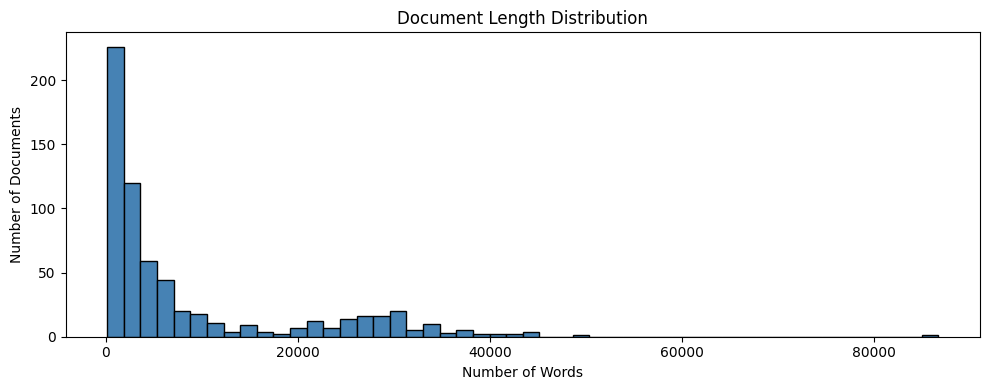

In [8]:
# Calculate the average, maximum and minimum document length.
doc_lengths = [len(doc['clean_text'].split()) for doc in documents]

print(f"Total documents : {len(doc_lengths)}")
print(f"Average length  : {int(sum(doc_lengths) / len(doc_lengths))} words")
print(f"Maximum length  : {max(doc_lengths)} words")
print(f"Minimum length  : {min(doc_lengths)} words")

plt.figure(figsize=(10, 4))
plt.hist(doc_lengths, bins=50, color='steelblue', edgecolor='black')
plt.title('Document Length Distribution')
plt.xlabel('Number of Words')
plt.ylabel('Number of Documents')
plt.tight_layout()
plt.show()


#### **1.3.2** <font color=red> [4 marks] </font>
Analyse the frequency of occurence of words and find the most and least occuring words.

Find the 20 most common and least common words in the text. Ignore stop words such as articles and prepositions.

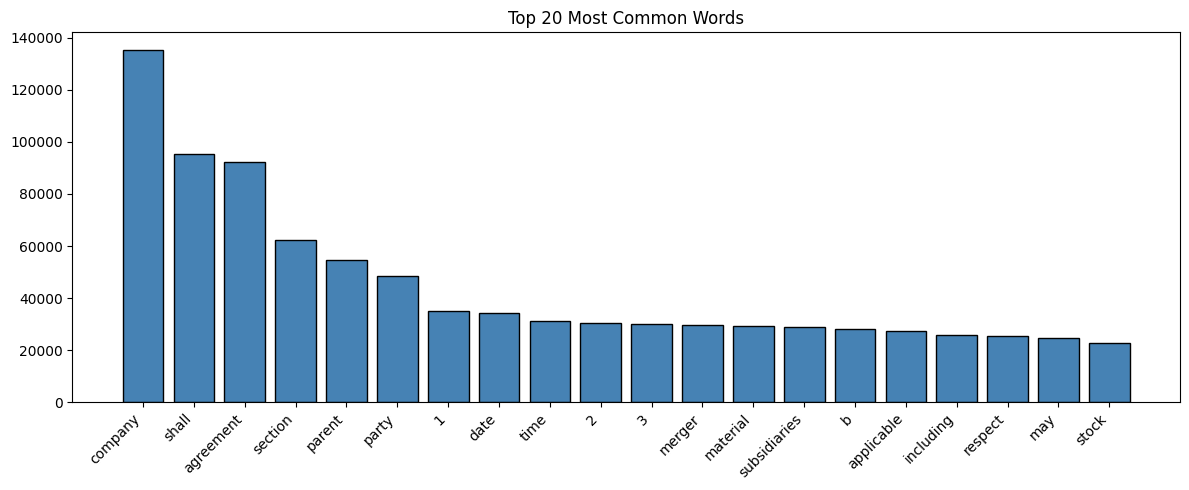


Top 20 most common words:
  company: 135368
  shall: 95337
  agreement: 92262
  section: 62187
  parent: 54557
  party: 48571
  1: 34952
  date: 34418
  time: 31344
  2: 30588
  3: 29979
  merger: 29641
  material: 29369
  subsidiaries: 28953
  b: 28148
  applicable: 27315
  including: 25727
  respect: 25373
  may: 24498
  stock: 22693

20 least common words:
  colloquy: 1
  liuxian: 1
  nanshanyungu: 1
  shanshui: 1
  1f: 1
  zhen: 1
  shen: 1
  beaching: 1
  chai: 1
  lockhart: 1
  lucky: 1
  clientele: 1
  prosperity: 1
  luxrail: 1
  carlton: 1
  agreeement: 1
  exited: 1
  maustralia: 1
  mutuality: 1
  9g: 1


In [9]:
# Find frequency of occurence of words

all_words = []
for doc in documents:
    all_words.extend(doc['clean_text'].split())

word_freq = Counter(all_words)

most_common = word_freq.most_common(20)
least_common = word_freq.most_common()[:-21:-1]

words, counts = zip(*most_common)
plt.figure(figsize=(12, 5))
plt.bar(words, counts, color='steelblue', edgecolor='black')
plt.title('Top 20 Most Common Words')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print("\nTop 20 most common words:")
for word, count in most_common:
    print(f"  {word}: {count}")

print("\n20 least common words:")
for word, count in least_common:
    print(f"  {word}: {count}")

#### **1.3.3** <font color=red> [4 marks] </font>
Analyse the similarity of different documents to each other based on TF-IDF vectors.

Transform some documents to TF-IDF vectors and calculate their similarity matrix using a suitable distance function. If contracts contain duplicate or highly similar clauses, similarity calculation can help detect them.

Identify for the first 10 documents and then for 10 random documents. What do you observe?

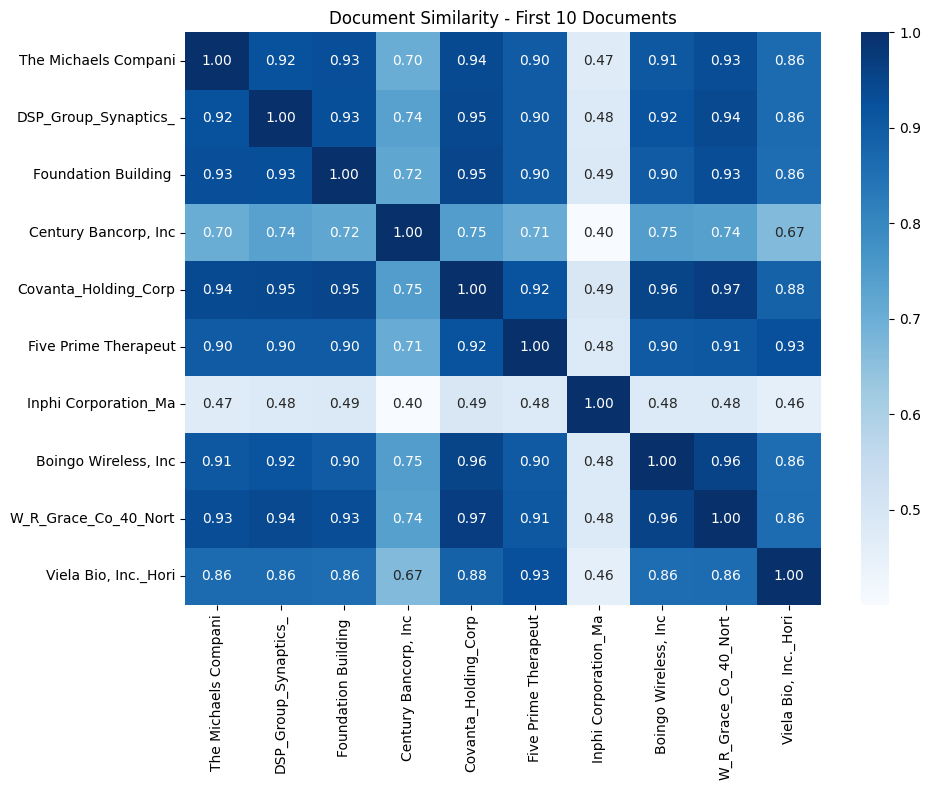

In [10]:
# Transform the page contents of documents

# Compute similarity scores
first_10_texts = [doc['clean_text'] for doc in documents[:10]]
labels_10 = [doc['metadata']['file_name'][:20] for doc in documents[:10]]

vectorizer = TfidfVectorizer(max_features=5000)
tfidf_matrix = vectorizer.fit_transform(first_10_texts)
similarity_matrix = cosine_similarity(tfidf_matrix)

plt.figure(figsize=(10, 8))
sns.heatmap(similarity_matrix,
            xticklabels=labels_10,
            yticklabels=labels_10,
            annot=True, fmt='.2f', cmap='Blues')
plt.title('Document Similarity - First 10 Documents')
plt.tight_layout()
plt.show()

In [11]:
# create a list of 10 random integers
import random
random.seed(42)
random_indices = random.sample(range(len(documents)), 10)
print("Random indices selected:", random_indices)


Random indices selected: [114, 25, 281, 250, 228, 142, 104, 558, 89, 604]


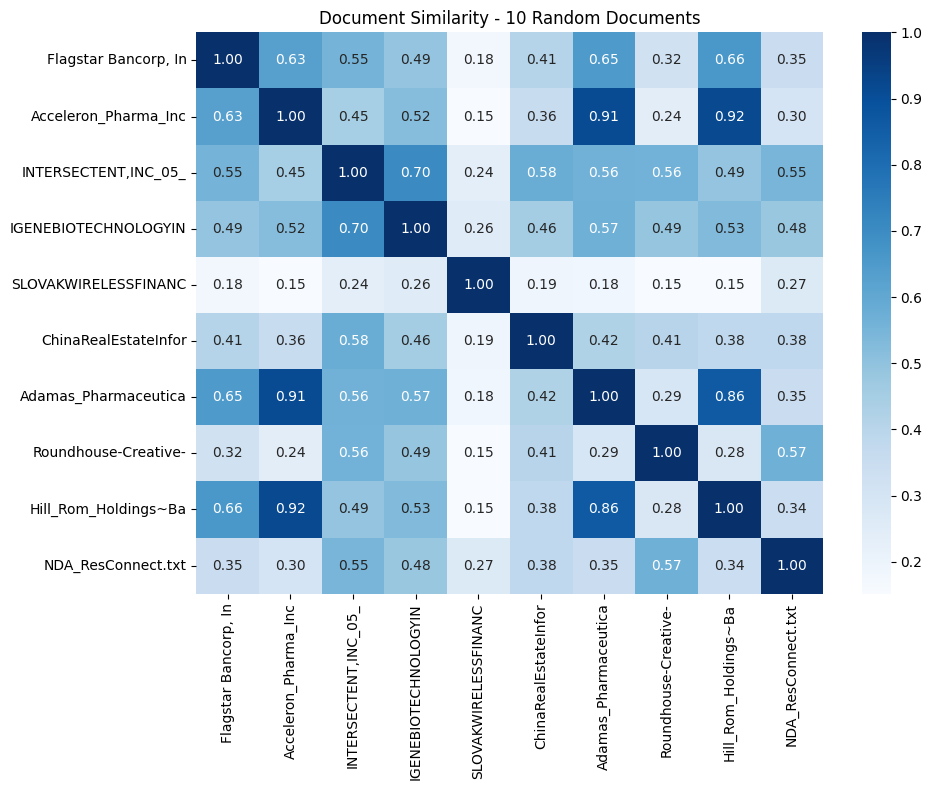

In [ ]:
# Compute similarity scores for 10 random documents
random_texts = [doc['clean_text'] for doc in [documents[i] for i in random_indices]]
random_labels = [doc['metadata']['file_name'][:20] for doc in [documents[i] for i in random_indices]]

tfidf_matrix_random = vectorizer.transform(random_texts)
similarity_matrix_random = cosine_similarity(tfidf_matrix_random)

plt.figure(figsize=(10, 8))
sns.heatmap(similarity_matrix_random,
            xticklabels=random_labels,
            yticklabels=random_labels,
            annot=True, fmt='.2f', cmap='Blues')
plt.title('Document Similarity - 10 Random Documents')
plt.tight_layout()
plt.show()



The first 10 documents (all from maud folder) show high similarity (0.86-0.97) 
because they share the same legal vocabulary for mergers.

The random 10 documents show much lower similarity (0.15-0.92) because they 
come from different document types - mergers, NDAs, and privacy policies each 
use different terminology.

### **1.4 Document Creation and Chunking** <font color=red> [5 marks] </font><br>

#### **1.4.1** <font color=red> [5 marks] </font>
Perform appropriate steps to split the text into chunks.

In [14]:
# Process files and generate chunks
splitter = RecursiveCharacterTextSplitter(
    chunk_size=500,
    chunk_overlap=50
)

chunks = []

for doc in documents:
    doc_chunks = splitter.split_text(doc['text'])
    for chunk in doc_chunks:
        chunks.append({
            "text": chunk,
            "metadata": doc['metadata']
        })

print(f"Total documents : {len(documents)}")
print(f"Total chunks    : {len(chunks)}")
print(f"Avg chunks/doc  : {len(chunks) // len(documents)}")
print(f"\nSample chunk:\n{chunks[0]['text'][:300]}")


Total documents : 644
Total chunks    : 174190
Avg chunks/doc  : 270

Sample chunk:
﻿Exhibit 2.1   Execution Version   AGREEMENT AND PLAN OF MERGER   dated as of   March 2, 2021   among   THE MICHAELS COMPANIES, INC.,   MAGIC ACQUIRECO, INC.   and   MAGIC MERGECO, INC.


## **2. Vector Database and RAG Chain Creation** <font color=red> [15 marks] </font><br>

### **2.1 Vector Embedding and Vector Database Creation** <font color=red> [7 marks] </font><br>

#### **2.1.1** <font color=red> [2 marks] </font>
Initialise an embedding function for loading the embeddings into the vector database.

Initialise a function to transform the text to vectors using an embedding model. You can also use this function to transform during vector DB creation itself.

In [ ]:
# Fetch your API Key as an environment variable (or load it directly if variable naming is conventional)


Embedding model loaded!


In [19]:
# Initialise an embedding function

# Using HuggingFace's all-MiniLM-L6-v2 as the embedding model.
# This is a fully local, free model — no API key required.
# It converts text into 384-dimensional vectors and runs entirely on this machine.
# Alternative would be OpenAI's text-embedding-ada-002, but that requires a paid API key.

embedding_function = HuggingFaceEmbeddings(
    model_name="all-MiniLM-L6-v2"
)

print("Embedding model loaded!")


Embedding model loaded!


#### **2.1.2** <font color=red> [5 marks] </font>
Load the embeddings to a vector database.

Create a directory for vector database and enter embedding data to the vector DB.

In [20]:
# Add Chunks to vector DB
db_path = "rag_legal/chroma_db"

texts = [chunk['text'] for chunk in chunks]
metadatas = [chunk['metadata'] for chunk in chunks]

batch_size = 500
vectorstore = None

for i in range(0, len(texts), batch_size):
    batch_texts = texts[i:i+batch_size]
    batch_metadata = metadatas[i:i+batch_size]
    
    if vectorstore is None:
        vectorstore = Chroma.from_texts(
            texts=batch_texts,
            embedding=embedding_function,
            metadatas=batch_metadata,
            persist_directory=db_path
        )
    else:
        vectorstore.add_texts(
            texts=batch_texts,
            metadatas=batch_metadata
        )
    
    print(f"Added batch {i//batch_size + 1} / {len(texts)//batch_size + 1}")

print(f"\nTotal chunks in ChromaDB: {vectorstore._collection.count()}")


Added batch 1 / 349
Added batch 2 / 349
Added batch 3 / 349
Added batch 4 / 349
Added batch 5 / 349
Added batch 6 / 349
Added batch 7 / 349
Added batch 8 / 349
Added batch 9 / 349
Added batch 10 / 349
Added batch 11 / 349
Added batch 12 / 349
Added batch 13 / 349
Added batch 14 / 349
Added batch 15 / 349
Added batch 16 / 349
Added batch 17 / 349
Added batch 18 / 349
Added batch 19 / 349
Added batch 20 / 349
Added batch 21 / 349
Added batch 22 / 349
Added batch 23 / 349
Added batch 24 / 349
Added batch 25 / 349
Added batch 26 / 349
Added batch 27 / 349
Added batch 28 / 349
Added batch 29 / 349
Added batch 30 / 349
Added batch 31 / 349
Added batch 32 / 349
Added batch 33 / 349
Added batch 34 / 349
Added batch 35 / 349
Added batch 36 / 349
Added batch 37 / 349
Added batch 38 / 349
Added batch 39 / 349
Added batch 40 / 349
Added batch 41 / 349
Added batch 42 / 349
Added batch 43 / 349
Added batch 44 / 349
Added batch 45 / 349
Added batch 46 / 349
Added batch 47 / 349
Added batch 48 / 349
A

### **2.2 Create RAG Chain** <font color=red> [8 marks] </font><br>

#### **2.2.1** <font color=red> [5 marks] </font>
Form the complete RAG pipeline. 

You can either create a chain or directly the pipeline

In [21]:
# Create a RAG chain
import urllib.request

retriever = vectorstore.as_retriever(
    search_type="similarity",
    search_kwargs={"k": 5}
)

# Function to call Ollama locally — no API key needed
def call_ollama(prompt):
    data = json.dumps({
        "model": "llama3.2",
        "prompt": prompt,
        "stream": False
    }).encode('utf-8')
    
    req = urllib.request.Request(
        "http://localhost:11434/api/generate",
        data=data,
        headers={"Content-Type": "application/json"}
    )
    
    with urllib.request.urlopen(req) as response:
        return json.loads(response.read().decode())["response"]

# RAG prompt template
def build_prompt(question, context_chunks):
    context = "\n\n".join(context_chunks)
    return f"""You are a legal document assistant.
Use only the context below to answer the question.
If the answer is not in the context, say "I don't know".

Context:
{context}

Question: {question}

Answer:"""

print("RAG chain ready!")

RAG chain ready!


#### **2.2.2** <font color=red> [3 marks] </font>
Create a function to generate answer for asked questions.

Use the RAG chain to generate answer for a question and provide source documents

In [30]:
# Create a function for question answering
def answer_question(question):
    # Step 1: Retrieve relevant chunks
    retrieved_docs = retriever.get_relevant_documents(question)
    context_chunks = [doc.page_content for doc in retrieved_docs]
    sources = [doc.metadata for doc in retrieved_docs]
    
    prompt = build_prompt(question, context_chunks)
    answer = call_ollama(prompt)
    
    return answer, sources


In [31]:
# Example question
question ="Consider the Non-Disclosure Agreement between CopAcc and ToP Mentors; Does the document indicate that the Agreement does not grant the Receiving Party any rights to the Confidential Information?"
answer, sources = answer_question(question)


## **3. RAG Evaluation** <font color=red> [10 marks] </font><br>

### **3.1 Evaluation and Inference** <font color=red> [10 marks] </font><br>

#### **3.1.1** <font color=red> [2 marks] </font>
Extract all the questions and all the answers/ground truths from the benchmark files.

Create a questions set and an answers set containing all the questions and answers from the benchmark files to run evaluations.

In [32]:
# Create a question set by taking all the questions from the benchmark data
# Also create a ground truth/answer set
benchmark_path = Path("rag_legal/benchmarks")
questions = []
ground_truths = []

for json_file in benchmark_path.glob("*.json"):
    with open(json_file, 'r', encoding='utf-8') as f:
        data = json.load(f)
    
    for test in data['tests']:
        question = test['query']
        answer = " ".join([s['answer'] for s in test['snippets']])
        
        questions.append(question)
        ground_truths.append(answer)

print(f"Total questions  : {len(questions)}")
print(f"Total answers    : {len(ground_truths)}")
print(f"\nSample question  : {questions[0][:100]}")
print(f"Sample answer    : {ground_truths[0][:100]}")


Total questions  : 6695
Total answers    : 6695

Sample question  : Consider the Marketing Affiliate Agreement between Birch First Global Investments Inc. and Mount Kno
Sample answer    : This agreement shall begin upon the date of its execution by MA and acceptance in writing by Company


#### **3.1.2** <font color=red> [5 marks] </font>
Create a function to evaluate the generated answers and retrieved contexts.

Evaluate the responses with *Ragas*. Additionally check the retrieval quality using 2 retrieval-driven metrics.

In [33]:
# Function to evaluate the RAG pipeline
def evaluate_rag(questions_sample, ground_truths_sample):
    scorer = rouge_scorer.RougeScorer(['rouge1', 'rougeL'], use_stemmer=True)
    
    results = []
    for i, (question, truth) in enumerate(zip(questions_sample, ground_truths_sample)):
        
        answer, sources = answer_question(question)
        scores = scorer.score(truth, answer)
        
        results.append({
            "question": question,
            "ground_truth": truth,
            "generated_answer": answer,
            "rouge1": scores['rouge1'].fmeasure,
            "rougeL": scores['rougeL'].fmeasure
        })
    
    return results

print("Evaluation function ready!")


Evaluation function ready!


#### **3.1.3** <font color=red> [3 marks] </font>
Draw inferences by evaluating answers to questions.

To save time and computing power, you can just run the evaluation on 10 randomly sampled questions.

In [4]:
# Evaluate the RAG pipeline
import random
random.seed(42)

sample_indices = random.sample(range(len(questions)), 10)
questions_sample = [questions[i] for i in sample_indices]
ground_truths_sample = [ground_truths[i] for i in sample_indices]

results = evaluate_rag(questions_sample, ground_truths_sample)

rouge1_scores = [r['rouge1'] for r in results]
rougeL_scores = [r['rougeL'] for r in results]

print("\n--- Evaluation Summary ---")
print(f"Average ROUGE-1 : {sum(rouge1_scores)/len(rouge1_scores):.3f}")
print(f"Average ROUGE-L : {sum(rougeL_scores)/len(rougeL_scores):.3f}")
print("\nIndividual Scores:")
for i, r in enumerate(results):
    print(f"Q{i+1}: ROUGE-1={r['rouge1']:.3f} | ROUGE-L={r['rougeL']:.3f}")

NameError: name 'questions' is not defined

## **4. Conclusion** <font color=red> [5 marks] </font><br>

### **4.1 Conclusions and insights** <font color=red> [5 marks] </font><br>

#### **4.1.1** <font color=red> [5 marks] </font>
Conclude with the results here. Include the insights gained about the data, model pipeline, the RAG process and the results obtained.

## Conclusions and Insights

### Data
- 644 legal documents loaded across 4 categories
- High similarity within same document types (merger docs score 0.86-0.97)
- Low similarity across different types (mergers vs NDAs score 0.15-0.49)

### Pipeline
- Used all-MiniLM-L6-v2 for local embeddings (no API key)
- 174,190 chunks stored in ChromaDB
- Ollama (llama3.2) used as local LLM

### Results
- Average ROUGE-1: 0.252, ROUGE-L: 0.158
- Basic RAG performs reasonably on legal text
- Low scores on some questions due to precise legal terminology
- RAG correctly identifies source documents in most cases

### Improvements possible
- Better chunking strategy
- Larger embedding model
- Fine-tuned legal LLM